# 05. Classic ML cho Phân tích Cảm xúc Đa khía cạnh (ABSA) - Tiếng Việt

Notebook này sử dụng Machine Learning truyền thống để giải quyết 2 bài toán:
1. **Phân loại cảm xúc tổng thể** (Overall Sentiment): Tiêu cực (0) / Trung lập (1) / Tích cực (2)
2. **Phân loại cảm xúc theo khía cạnh** (Aspect Sentiment): 6 khía cạnh × {Tiêu cực / Trung lập / Tích cực / Không đề cập}

> **Lưu ý quan trọng**: Nhãn **Trung lập (Neutral)** trong dataset = **vừa khen vừa chê** (mixed sentiment),
> không phải "không có ý kiến". Điều này ảnh hưởng trực tiếp đến chiến lược feature engineering.

**Các kỹ thuật chính:**
- Tách từ tiếng Việt bằng `pyvi`
- Feature engineering: contrastive markers, mixed sentiment detection, aspect lexicon
- TF-IDF với cấu hình riêng cho Overall vs. Aspect
- Xử lý mất cân bằng dữ liệu: `class_weight` tuỳ chỉnh, neutral threshold tuning

## 1. Import và Cấu hình

In [14]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import hstack, csr_matrix
from IPython.display import display
from pyvi import ViTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
)

# ── Cấu hình chung ──
SEED = 42
np.random.seed(SEED)

PROJECT_ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path(r"D:/DataPreprocessing/DoAn2"),
]
PROJECT_ROOT = next(
    (p for p in PROJECT_ROOT_CANDIDATES if (p / "data" / "processed" / "train_clean.json").exists()),
    Path.cwd(),
)

DATA_DIR = PROJECT_ROOT / "data" / "processed"
TRAIN_PATH = DATA_DIR / "train_clean.json"
VAL_PATH = DATA_DIR / "val_clean.json"
TEST_PATH = DATA_DIR / "test_clean.json"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "classic_ml_absa_v2"

TEXT_COL = "content"
SENT_COL = "sentiment_llm"
ASPECT_COLS = ["as_content", "as_physical", "as_price", "as_packaging", "as_delivery", "as_service"]
ASPECT_NAMES = {
    "as_content": "content", "as_physical": "physical", "as_price": "price",
    "as_packaging": "packaging", "as_delivery": "delivery", "as_service": "service",
}

SENTIMENT_ID_TO_TEXT = {0: "neg", 1: "neu", 2: "pos"}
SENTIMENT_LABELS = ["neg", "neu", "pos"]
ASPECT_LABELS = ["neg", "neu", "pos", "absent"]

# ── Cấu hình TF-IDF riêng cho từng bài toán ──
TFIDF_OVERALL_CONFIG = {
    "ngram_range": (1, 2),
    "max_features": 30000,
    "sublinear_tf": True,
    "min_df": 2,
    "max_df": 0.95,
    "tokenizer": str.split,
    "token_pattern": None,
}
TFIDF_OVERALL_CHAR_CONFIG = {
    "analyzer": "char_wb",
    "ngram_range": (3, 5),
    "max_features": 25000,
    "sublinear_tf": True,
    "min_df": 2,
    "max_df": 0.95,
}
TFIDF_ASPECT_CONFIG = {
    "ngram_range": (1, 2),
    "max_features": 30000,
    "sublinear_tf": True,
    "min_df": 1,
    "max_df": 0.95,
    "tokenizer": str.split,
    "token_pattern": None,
}
TFIDF_ASPECT_CHAR_CONFIG = {
    "analyzer": "char_wb",
    "ngram_range": (3, 5),
    "max_features": 25000,
    "sublinear_tf": True,
    "min_df": 2,
    "max_df": 0.95,
}

# ── Từ điển cho Feature Engineering ──
# Từ positive phổ biến (đã tách từ pyvi)
POS_WORDS = {
    "hay", "đẹp", "tốt", "nhanh", "thích", "ổn", "chất_lượng", "tuyệt", "tuyệt_vời",
    "hài_lòng", "xuất_sắc", "hoàn_hảo", "ưng", "yêu", "đáng_tiền", "rẻ", "giá_rẻ",
    "nhanh_chóng", "cẩn_thận", "chắc_chắn", "đáng_đọc", "bổ_ích",
}
# Từ negative phổ biến
NEG_WORDS = {
    "xấu", "chậm", "nhàu", "rách", "tệ", "lỗi", "méo", "mờ", "bẩn", "hỏng",
    "thất_vọng", "tồi", "kém", "dở", "nhạt", "sai", "chán", "đắt", "mắc",
    "trễ", "muộn", "hư", "mỏng", "bong", "tróc", "nhòe", "gãy",
}
# Từ trung lập / hedging
NEUTRAL_WORDS = {
    "tạm", "tạm_được", "cũng_ổn", "bình_thường", "tạm_ổn", "được",
    "cũng_được", "không_tệ", "chấp_nhận", "vừa_phải", "hơi",
}
# Từ đối lập (contrastive markers) – dấu hiệu #1 của mixed sentiment
CONTRASTIVE_WORDS = {
    "nhưng", "tuy_nhiên", "tuy", "mặc_dù", "dù", "song", "thế_nhưng",
    "tuy_vậy", "bù_lại", "nhưng_mà", "trừ", "ngoại_trừ",
}
# Từ nhấn mạnh (intensifiers) – cảm xúc mạnh = không neutral
INTENSIFIER_WORDS = {
    "rất", "quá", "cực_kỳ", "vô_cùng", "siêu", "tuyệt_đối",
    "hết_sức", "vô_cùng", "cực", "khá",
}
# Từ khóa cho từng aspect
ASPECT_LEXICONS = {
    "content": {"nội_dung", "cốt_truyện", "chương", "dịch", "dịch_thuật", "văn_phong", "kiến_thức", "bài_học", "câu_chuyện", "tác_giả"},
    "physical": {"bìa", "giấy", "in_ấn", "gáy", "mực", "bookmark", "bìa_cứng", "bìa_mềm", "khổ", "trang"},
    "price": {"giá", "tiền", "đắt", "rẻ", "sale", "đáng_tiền", "giá_cả", "giảm_giá", "mắc", "phí"},
    "packaging": {"đóng_gói", "hộp", "bọc", "chống_sốc", "bubble", "gói", "bao_bì", "nilon", "carton", "móp"},
    "delivery": {"giao_hàng", "giao", "shipper", "vận_chuyển", "ship", "tốc_độ", "ngày", "freeship", "giao_nhanh"},
    "service": {"tư_vấn", "đổi_trả", "thái_độ", "shop", "tiki", "fahasa", "nhân_viên", "hỗ_trợ", "phục_vụ", "chăm_sóc"},
}


def normalize_lexicon_text(text):
    return " ".join(str(text).lower().replace("_", " ").split())


def count_lexicon_hits(text, terms):
    normalized_text = f" {normalize_lexicon_text(text)} "
    return sum(
        1
        for term in terms
        if f" {normalize_lexicon_text(term)} " in normalized_text
    )


def has_any_lexicon_term(text, terms):
    normalized_text = f" {normalize_lexicon_text(text)} "
    return int(
        any(
            f" {normalize_lexicon_text(term)} " in normalized_text
            for term in terms
        )
    )


def bin_review_length(word_count):
    if word_count < 5:
        return 0
    if word_count <= 20:
        return 1
    if word_count <= 50:
        return 2
    return 3


sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

print("Project root:", PROJECT_ROOT)
print("Train:", TRAIN_PATH)
print("Val:", VAL_PATH)
print("Test:", TEST_PATH)


Project root: d:\DataPreprocessing\DoAn2
Train: d:\DataPreprocessing\DoAn2\data\processed\train_clean.json
Val: d:\DataPreprocessing\DoAn2\data\processed\val_clean.json
Test: d:\DataPreprocessing\DoAn2\data\processed\test_clean.json


## 2. Nạp dữ liệu và Phân tích phân bố

Dữ liệu đã được làm sạch sẵn. Ta chỉ cần nạp và xem phân bố nhãn để hiểu mức độ mất cân bằng.

In [15]:
df_train = pd.read_json(TRAIN_PATH)
df_val = pd.read_json(VAL_PATH)
df_test = pd.read_json(TEST_PATH)

print(f"Train: {df_train.shape}  Val: {df_val.shape}  Test: {df_test.shape}")

# ── Phân bố cảm xúc tổng thể ──
sent_vc = df_train[SENT_COL].value_counts().sort_index()
sent_dist = pd.DataFrame({
    "label_id": sent_vc.index.astype(int),
    "label": [SENTIMENT_ID_TO_TEXT[int(i)] for i in sent_vc.index],
    "count": sent_vc.values,
})
sent_dist["percent"] = (sent_dist["count"] / sent_dist["count"].sum() * 100).round(2)
print("\n=== Phân bố cảm xúc tổng thể (train) ===")
display(sent_dist)

# ── Phân bố aspect ──
print("\n=== Phân bố aspect (train) ===")
for col in ASPECT_COLS:
    n_present = df_train[col].notna().sum()
    pct = round(n_present / len(df_train) * 100, 1)
    print(f"  {ASPECT_NAMES[col]:>12s}: {n_present:>5d} present ({pct}%)")


Train: (9362, 9)  Val: (2006, 9)  Test: (2006, 9)

=== Phân bố cảm xúc tổng thể (train) ===


,label_id,label,count,percent
0,0,neg,4909,52.44
1,1,neu,1526,16.30
2,2,pos,2927,31.26



=== Phân bố aspect (train) ===
       content:  2860 present (30.5%)
      physical:  3573 present (38.2%)
         price:   887 present (9.5%)
     packaging:  1699 present (18.1%)
      delivery:  2391 present (25.5%)
       service:   278 present (3.0%)


## 3. Tách từ tiếng Việt bằng `pyvi`

Sử dụng `ViTokenizer` để tách từ. Các từ ghép được nối bằng dấu `_` (ví dụ: `hài_lòng`, `giao_hàng`).

In [16]:
def tokenize_text(series):
    # Tokenize Vietnamese text with pyvi.
    return series.fillna("").astype(str).apply(ViTokenizer.tokenize)

for frame in [df_train, df_val, df_test]:
    frame["content_seg"] = tokenize_text(frame[TEXT_COL])


## 4. Feature Engineering

Tạo các đặc trưng bổ sung từ nội dung text:
- **`word_count`**: Số từ trong review
- **`exclamation_count`**: Số dấu `!` (cảm xúc mạnh)
- **`question_count`**: Số dấu `?` (hoài nghi)
- **`neutral_lexicon_count`**: Đếm từ neutral ("tạm", "cũng ổn"...)
- **`contrastive_count`**: Đếm từ đối lập ("nhưng", "tuy nhiên"...) – dấu hiệu #1 của vừa khen vừa chê
- **`intensifier_count`**: Đếm từ nhấn mạnh ("rất", "quá"...) – cảm xúc mạnh
- **`has_both_pos_neg`**: Câu có CẢ từ khen VÀ từ chê? – dấu hiệu #2 của mixed sentiment
- **`as_{aspect}_lexicon`**: Đếm từ khóa thuộc từng aspect

In [17]:
NEGATION_WORDS = {"không", "chẳng", "chưa", "đừng", "chả", "không hề", "không phải", "chưa hẳn"}


def has_both_pos_neg(text):
    # Kiểm tra câu có CẢ từ positive VÀ negative → dấu hiệu mixed sentiment.
    return int(
        has_any_lexicon_term(text, POS_WORDS)
        and has_any_lexicon_term(text, NEG_WORDS)
    )


def build_features(df):
    # Tạo DataFrame chứa các features bổ sung từ nội dung text.
    text_col = df["content_seg"].fillna("").astype(str)
    raw_col = df[TEXT_COL].fillna("")

    features = pd.DataFrame(index=df.index)
    word_count = text_col.apply(lambda x: len(x.split()))
    features["review_length_bin"] = word_count.apply(bin_review_length)
    features["exclamation_count"] = raw_col.str.count("!")
    features["question_count"] = raw_col.str.count(r"\?")
    features["neutral_lexicon_count"] = text_col.apply(lambda x: count_lexicon_hits(x, NEUTRAL_WORDS))
    features["contrastive_count"] = text_col.apply(lambda x: count_lexicon_hits(x, CONTRASTIVE_WORDS))
    features["intensifier_count"] = text_col.apply(lambda x: count_lexicon_hits(x, INTENSIFIER_WORDS))
    features["has_negation"] = text_col.apply(lambda x: int(count_lexicon_hits(x, NEGATION_WORDS) > 0))
    features["has_both_pos_neg"] = text_col.apply(has_both_pos_neg)
    features["mixed_signal_score"] = features["contrastive_count"] * features["has_both_pos_neg"]

    # Aspect lexicon features
    for aspect_name, lexicon in ASPECT_LEXICONS.items():
        features[f"lex_{aspect_name}"] = text_col.apply(
            lambda x, lexicon=lexicon: count_lexicon_hits(x, lexicon)
        )

    return features


feat_train = build_features(df_train)
feat_val = build_features(df_val)
feat_test = build_features(df_test)

print(f"Features shape: {feat_train.shape}")
print(f"Feature columns: {list(feat_train.columns)}")
display(feat_train.describe().round(2))


Features shape: (9362, 15)
Feature columns: ['review_length_bin', 'exclamation_count', 'question_count', 'neutral_lexicon_count', 'contrastive_count', 'intensifier_count', 'has_negation', 'has_both_pos_neg', 'mixed_signal_score', 'lex_content', 'lex_physical', 'lex_price', 'lex_packaging', 'lex_delivery', 'lex_service']


,review_length_bin,exclamation_count,question_count,neutral_lexicon_count,contrastive_count,intensifier_count,has_negation,has_both_pos_neg,mixed_signal_score,lex_content,lex_physical,lex_price,lex_packaging,lex_delivery,lex_service
count,9362.00,9362.00,9362.00,9362.00,9362.00,9362.00,9362.00,9362.00,9362.00,9362.00,9362.00,9362.00,9362.00,9362.00,9362.00
mean,1.49,0.11,0.08,0.34,0.34,0.44,0.45,0.17,0.12,0.29,0.35,0.17,0.45,0.55,0.25
std,0.77,0.46,0.42,0.59,0.67,0.64,0.50,0.37,0.45,0.59,0.67,0.49,0.91,0.89,0.50
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,2.00,0.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
max,3.00,9.00,9.00,6.00,6.00,5.00,1.00,1.00,6.00,5.00,6.00,5.00,7.00,5.00,5.00


## 5. TF-IDF Vectorization

- Dùng `tokenizer=str.split` vì `pyvi` đã tách từ sẵn (từ ghép nối bằng `_`)
- TF-IDF cấu hình **riêng** cho Overall Sentiment vs. Aspect Sentiment
- Kết hợp TF-IDF + features bằng `scipy.sparse.hstack`

In [18]:
def features_to_sparse(feat_df):
    # Chuyển DataFrame features sang sparse matrix.
    return csr_matrix(feat_df.values.astype(float))


# ── TF-IDF cho Overall Sentiment ──
tfidf_overall = TfidfVectorizer(**TFIDF_OVERALL_CONFIG)
tfidf_overall_char = TfidfVectorizer(**TFIDF_OVERALL_CHAR_CONFIG)
X_overall_tfidf_train = tfidf_overall.fit_transform(df_train["content_seg"])
X_overall_tfidf_val = tfidf_overall.transform(df_val["content_seg"])
X_overall_tfidf_test = tfidf_overall.transform(df_test["content_seg"])

X_overall_char_train = tfidf_overall_char.fit_transform(df_train["content_seg"])
X_overall_char_val = tfidf_overall_char.transform(df_val["content_seg"])
X_overall_char_test = tfidf_overall_char.transform(df_test["content_seg"])

# Kết hợp TF-IDF + features
X_overall_train = hstack([X_overall_tfidf_train, X_overall_char_train, features_to_sparse(feat_train)])
X_overall_val = hstack([X_overall_tfidf_val, X_overall_char_val, features_to_sparse(feat_val)])
X_overall_test = hstack([X_overall_tfidf_test, X_overall_char_test, features_to_sparse(feat_test)])

# Labels
y_sent_train = df_train[SENT_COL].astype(int).map(SENTIMENT_ID_TO_TEXT).to_numpy(dtype=object)
y_sent_val = df_val[SENT_COL].astype(int).map(SENTIMENT_ID_TO_TEXT).to_numpy(dtype=object)
y_sent_test = df_test[SENT_COL].astype(int).map(SENTIMENT_ID_TO_TEXT).to_numpy(dtype=object)

print(f"Overall TF-IDF word features: {X_overall_tfidf_train.shape[1]}")
print(f"Overall TF-IDF char features: {X_overall_char_train.shape[1]}")
print(f"Engineering features: {feat_train.shape[1]}")
print(f"Combined Overall features: {X_overall_train.shape}")


Overall TF-IDF word features: 27691
Overall TF-IDF char features: 25000
Engineering features: 15
Combined Overall features: (9362, 52706)


## 6. Overall Sentiment Classification

- Logistic Regression balanced
- Handle imbalance with custom `class_weight`


In [19]:
def print_report(title, y_true, y_pred, labels, target_names=None):
    # In classification report with a consistent format.
    print(f"\n=== {title} ===")
    kwargs = dict(labels=labels, digits=4, zero_division=0)
    if target_names is not None:
        kwargs["target_names"] = target_names
    print(classification_report(y_true, y_pred, **kwargs))


def macro_f1(y_true, y_pred, labels):
    return float(f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0))


def compute_absa_metrics(y_sent_true, y_sent_pred, y_aspect_true, y_aspect_pred, df_aspect):
    y_sent_true = np.asarray(y_sent_true)
    y_sent_pred = np.asarray(y_sent_pred)
    y_aspect_true = np.asarray(y_aspect_true)
    y_aspect_pred = np.asarray(y_aspect_pred)

    f1_sent = macro_f1(y_sent_true, y_sent_pred, SENTIMENT_LABELS)

    aspect_true_flat = y_aspect_true.reshape(-1)
    aspect_pred_flat = y_aspect_pred.reshape(-1)
    f1_aspect_all = float(
        f1_score(
            aspect_true_flat,
            aspect_pred_flat,
            labels=ASPECT_LABELS,
            average="macro",
            zero_division=0,
        )
    )

    present_mask = aspect_true_flat != "absent"
    if present_mask.any():
        f1_aspect_present = float(
            f1_score(
                aspect_true_flat[present_mask],
                aspect_pred_flat[present_mask],
                labels=SENTIMENT_LABELS,
                average="macro",
                zero_division=0,
            )
        )
    else:
        f1_aspect_present = 0.0

    metrics = {
        "f1_sentiment": round(f1_sent, 4),
        "f1_aspect_all": round(f1_aspect_all, 4),
        "f1_aspect_present": round(f1_aspect_present, 4),
        "f1_combined": round(0.6 * f1_sent + 0.4 * f1_aspect_present, 4),
        "accuracy": round(
            accuracy_score(
                np.concatenate([y_sent_true, aspect_true_flat]),
                np.concatenate([y_sent_pred, aspect_pred_flat]),
            ),
            4,
        ),
    }
    metrics.update(aspect_present_f1s(y_aspect_true, y_aspect_pred, df_aspect))
    return metrics


# Final overall sentiment model.
lr_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED)
lr_model.fit(X_overall_train, y_sent_train)

best_overall_pred_val = lr_model.predict(X_overall_val)
best_overall_pred_test = lr_model.predict(X_overall_test)
best_overall_method = "LogReg Balanced"
best_overall_val_f1 = macro_f1(y_sent_val, best_overall_pred_val, SENTIMENT_LABELS)
best_overall_f1 = macro_f1(y_sent_test, best_overall_pred_test, SENTIMENT_LABELS)

print_report(f"{best_overall_method} - Val", y_sent_val, best_overall_pred_val, SENTIMENT_LABELS)
print_report(f"{best_overall_method} - Test", y_sent_test, best_overall_pred_test, SENTIMENT_LABELS)
print(
    f"\n>>> Final overall sentiment: {best_overall_method} "
    f"(val macro_f1 = {best_overall_val_f1:.4f}, test macro_f1 = {best_overall_f1:.4f})"
)



=== LogReg Balanced - Val ===
              precision    recall  f1-score   support

         neg     0.9163    0.8754    0.8954      1051
         neu     0.5515    0.6564    0.5994       326
         pos     0.8697    0.8490    0.8592       629

    accuracy                         0.8315      2006
   macro avg     0.7792    0.7936    0.7847      2006
weighted avg     0.8424    0.8315    0.8359      2006


=== LogReg Balanced - Test ===
              precision    recall  f1-score   support

         neg     0.9108    0.8831    0.8967      1052
         neu     0.5692    0.6768    0.6184       328
         pos     0.8960    0.8530    0.8740       626

    accuracy                         0.8400      2006
   macro avg     0.7920    0.8043    0.7964      2006
weighted avg     0.8503    0.8400    0.8441      2006


>>> Final overall sentiment: LogReg Balanced (val macro_f1 = 0.7847, test macro_f1 = 0.7964)


## 7. Chuẩn bị dữ liệu Aspect (Long-format)

Chuyển dữ liệu từ wide → long: mỗi review × 6 aspect. Thêm aspect lexicon count.

In [20]:
def build_aspect_long(df, feat_df):
    """
    Hàm chuyển đổi dữ liệu từ dạng 'Rộng' (mỗi câu 1 dòng, nhiều cột aspect) 
    sang dạng 'Dài' (mỗi cặp câu-khía cạnh là 1 dòng) để huấn luyện mô hình.
    """
    frames = []
    # Chuyển nội dung văn bản gốc sang dạng mảng numpy để xử lý nhanh hơn
    raw_text = df[TEXT_COL].fillna("").astype(str).to_numpy()
    
    # Duyệt qua từng cột khía cạnh (content, physical, price, packaging, delivery, service)
    for col in ASPECT_COLS:
        aspect_name = ASPECT_NAMES[col] # Lấy tên thân thiện (ví dụ: 'price' thay vì 'as_price')
        
        # Chuyển đổi nhãn từ ID (0,1,2) sang chữ (neg, neu, pos). 
        # Những dòng trống (NaN) được coi là 'absent' (không nhắc tới khía cạnh này).
        labels = df[col].map(SENTIMENT_ID_TO_TEXT).fillna("absent").to_numpy(dtype=object)
        
        # Tạo một DataFrame tạm thời cho khía cạnh hiện tại
        temp = pd.DataFrame({
            "review_id": df["review_id"].values,
            "aspect": aspect_name,
            "text_seg": df["content_seg"].values, # Văn bản đã tách từ (có dấu _)
            "text_raw": raw_text,                # Văn bản gốc
            "label": labels,                     # Nhãn sắc thái (neg/neu/pos/absent)
            
            # Tạo chuỗi "Prompt" giúp mô hình hiểu ngữ cảnh: "Khía cạnh nào | Review nào"
            # model_input: dùng cho Vectorizer dựa trên từ (Word-level)
            "model_input": "aspect: " + aspect_name + " | review: " + df["content_seg"].values,
            
            # model_input_char: dùng cho Vectorizer dựa trên ký tự (Char-level)
            "model_input_char": "aspect: " + aspect_name + " | review: " + raw_text,
        })
        
        # Gắn thêm các đặc trưng thủ công (manual features) đã tính toán từ bước 'build_features'
        for fc in feat_df.columns:
            temp[fc] = feat_df[fc].values
            
        # Thêm bảng tạm của khía cạnh này vào danh sách tổng
        frames.append(temp)
        
    # Nối tất cả các bảng của 6 khía cạnh lại thành một DataFrame duy nhất (Dạng Dài)
    return pd.concat(frames, ignore_index=True)

# Áp dụng hàm cho cả 3 tập dữ liệu Train, Val, Test
df_as_train = build_aspect_long(df_train, feat_train)
df_as_val = build_aspect_long(df_val, feat_val)
df_as_test = build_aspect_long(df_test, feat_test)

# In ra số lượng dòng sau khi chuyển đổi (sẽ gấp 6 lần số lượng review ban đầu)
print(f"Aspect long-format: train={len(df_as_train)}, val={len(df_as_val)}, test={len(df_as_test)}")

# Thống kê phân bổ nhãn trên tập huấn luyện
label_dist = df_as_train["label"].value_counts()
print("\n=== Aspect label distribution (train) ===")
for lbl in ASPECT_LABELS:
    cnt = int(label_dist.get(lbl, 0)) # Lấy số lượng của từng nhãn (neg, neu, pos, absent)
    pct = cnt / len(df_as_train) * 100 # Tính phần trăm
    # In ra định dạng:  Nhãn:  Số lượng (Tỉ lệ%)
    print(f"  {lbl:>7s}: {cnt:>6d} ({pct:5.2f}%)")

y_asp_train = df_as_train["label"].to_numpy(dtype=object)
y_asp_val = df_as_val["label"].to_numpy(dtype=object)
y_asp_test = df_as_test["label"].to_numpy(dtype=object)


Aspect long-format: train=56172, val=12036, test=12036

=== Aspect label distribution (train) ===
      neg:   3909 ( 6.96%)
      neu:   1815 ( 3.23%)
      pos:   5964 (10.62%)
   absent:  44484 (79.19%)


## 8. B&#224;i to&#225;n 2 &#8211; Ph&#226;n lo&#7841;i c&#7843;m x&#250;c theo kh&#237;a c&#7841;nh

Pipeline cu&#7889;i d&#249;ng 2 b&#432;&#7899;c: gate present/absent + sentiment neg/neu/pos cho t&#7915;ng aspect.


## 9. Chu&#7849;n b&#7883; d&#7919; li&#7879;u v&#224; &#273;&#7863;c tr&#432;ng Aspect


### 9.1. T&#7841;o TF-IDF word/char v&#224; &#273;&#7863;c tr&#432;ng th&#7911; c&#244;ng


In [21]:
aspect_feat_cols = feat_train.columns.tolist()

# TF-IDF for aspect long-format
aspect_tfidf_word = TfidfVectorizer(**TFIDF_ASPECT_CONFIG)
aspect_tfidf_char = TfidfVectorizer(**TFIDF_ASPECT_CHAR_CONFIG)

X_asp_tfidf_word_train = aspect_tfidf_word.fit_transform(df_as_train["model_input"])
X_asp_tfidf_word_val = aspect_tfidf_word.transform(df_as_val["model_input"])
X_asp_tfidf_word_test = aspect_tfidf_word.transform(df_as_test["model_input"])

X_asp_tfidf_char_train = aspect_tfidf_char.fit_transform(df_as_train["model_input_char"])
X_asp_tfidf_char_val = aspect_tfidf_char.transform(df_as_val["model_input_char"])
X_asp_tfidf_char_test = aspect_tfidf_char.transform(df_as_test["model_input_char"])

X_asp_train = hstack([
    X_asp_tfidf_word_train,
    X_asp_tfidf_char_train,
    features_to_sparse(df_as_train[aspect_feat_cols]),
])
X_asp_val = hstack([
    X_asp_tfidf_word_val,
    X_asp_tfidf_char_val,
    features_to_sparse(df_as_val[aspect_feat_cols]),
])
X_asp_test = hstack([
    X_asp_tfidf_word_test,
    X_asp_tfidf_char_test,
    features_to_sparse(df_as_test[aspect_feat_cols]),
])

print(f"Aspect TF-IDF word features: {X_asp_tfidf_word_train.shape[1]}")
print(f"Aspect TF-IDF char features: {X_asp_tfidf_char_train.shape[1]}")
print(f"Aspect feature columns: {len(aspect_feat_cols)}")
print(f"Combined Aspect features: {X_asp_train.shape}")


Aspect TF-IDF word features: 30000
Aspect TF-IDF char features: 25000
Aspect feature columns: 15
Combined Aspect features: (56172, 55015)


In [22]:
# --- GIAI ĐOẠN 1: BỘ LỌC (GATE) ĐỂ XÁC ĐỊNH KHÍA CẠNH CÓ XUẤT HIỆN HAY KHÔNG ---

def predict_stage1_gate(model, X, threshold):
    """Hàm dự đoán nhanh: Nếu điểm số từ mô hình >= ngưỡng thì coi là 'có nhắc tới' (present)."""
    scores = model.decision_function(X) # Lấy điểm tin cậy (distance to hyperplane) từ SVM
    if getattr(scores, "ndim", 1) > 1:
        scores = scores.ravel() # Đảm bảo mảng điểm số là mảng 1 chiều
    return np.where(scores >= threshold, "present", "absent") # So sánh với ngưỡng để ra quyết định

def calibrate_binary_threshold(scores, y_true, *, min_precision=0.25):
    """Hàm tìm ngưỡng (threshold) tối ưu để cân bằng giữa việc nhận diện đúng và không bỏ sót."""
    scores = np.asarray(scores)
    y_true = np.asarray(y_true)
    if scores.size == 0:
        return 0.5, 0.0, 0.0, 0.0
    
    # Tạo danh sách các ngưỡng thử nghiệm dựa trên các phân vị (quantiles) của điểm số
    thresholds = np.unique(np.concatenate(([0.0], np.quantile(scores, np.linspace(0.05, 0.95, 19)))))
    
    best_threshold = 0.5
    best_score = -1.0
    best_precision = 0.0
    best_recall = 0.0
    
    for threshold in thresholds:
        y_pred = (scores >= threshold).astype(int) # Dự đoán thử với ngưỡng hiện tại
        precision = precision_score(y_true, y_pred, zero_division=0) # Tính độ chính xác
        
        # Nếu ngưỡng thấp mà độ chính xác quá tệ (< 25%) thì bỏ qua để tránh đoán bừa
        if threshold < 0.5 and precision < min_precision:
            continue
            
        score = f1_score(y_true, y_pred, zero_division=0) # Tính điểm F1 (cân bằng Precision/Recall)
        if score > best_score: # Nếu tìm thấy ngưỡng tốt hơn thì lưu lại
            best_score = float(score)
            best_threshold = float(threshold)
            best_precision = float(precision)
            best_recall = float(recall_score(y_true, y_pred, zero_division=0))
            
    return best_threshold, best_score, best_precision, best_recall

# Khởi tạo các từ điển để lưu trữ mô hình và kết quả cho từng khía cạnh (aspect)
asp_stage1_models = {}
best_stage1_thresholds = {}
best_stage1_val_binary_f1s = {}
best_stage1_test_binary_f1s = {}
stage1_gate_rows = []

# Duyệt qua từng khía cạnh (ví dụ: nội dung, giá cả, dịch vụ...)
for aspect_col, aspect_name in ASPECT_NAMES.items():
    # Lấy mặt nạ (mask) để lọc đúng dữ liệu của khía cạnh đang xét
    train_mask = (df_as_train["aspect"] == aspect_name).to_numpy()
    val_mask = (df_as_val["aspect"] == aspect_name).to_numpy()
    test_mask = (df_as_test["aspect"] == aspect_name).to_numpy()

    # Chuẩn bị nhãn nhị phân: 1 nếu nhãn khác 'absent' (có nhắc tới), ngược lại là 0
    y_gate_train = (y_asp_train[train_mask] != "absent").astype(int)
    y_gate_val = (y_asp_val[val_mask] != "absent").astype(int)
    y_gate_test = (y_asp_test[test_mask] != "absent").astype(int)

    # Huấn luyện mô hình SVM (LinearSVC) chuyên biệt để phát hiện sự xuất hiện của khía cạnh này
    gate_model = LinearSVC(class_weight="balanced", max_iter=2000, random_state=SEED)
    gate_model.fit(X_asp_train[train_mask], y_gate_train)

    # Tìm ngưỡng tốt nhất trên tập Validation để mô hình hoạt động ổn định nhất
    val_scores = gate_model.decision_function(X_asp_val[val_mask])
    threshold, val_f1, val_precision, val_recall = calibrate_binary_threshold(val_scores, y_gate_val, min_precision=0.25)

    # Áp dụng ngưỡng vừa tìm được để dự đoán trên tập Test
    test_scores = gate_model.decision_function(X_asp_test[test_mask])
    test_gate_pred = (test_scores >= threshold).astype(int)

    # Tính toán các chỉ số đánh giá cuối cùng cho Giai đoạn 1
    test_f1 = f1_score(y_gate_test, test_gate_pred, zero_division=0)
    test_precision = precision_score(y_gate_test, test_gate_pred, zero_division=0)
    test_recall = recall_score(y_gate_test, test_gate_pred, zero_division=0)

    # Lưu mô hình và các thông số vào từ điển
    asp_stage1_models[aspect_name] = gate_model
    best_stage1_thresholds[aspect_name] = float(threshold)
    best_stage1_val_binary_f1s[aspect_name] = float(val_f1)
    best_stage1_test_binary_f1s[aspect_name] = float(test_f1)

    # Lưu thông tin chi tiết để in bảng tổng kết sau này
    stage1_gate_rows.append({
        "aspect": aspect_name,
        "threshold": float(threshold),
        "train_present": int(y_gate_train.sum()),
        "val_present": int(y_gate_val.sum()),
        "test_present": int(y_gate_test.sum()),
        "val_binary_f1": float(val_f1),
        "val_precision": float(val_precision),
        "val_recall": float(val_recall),
        "test_binary_f1": float(test_f1),
        "test_precision": float(test_precision),
        "test_recall": float(test_recall),
    })
    print(f"  {aspect_name:12s} threshold={threshold:.4f} val_f1={val_f1:.4f} test_f1={test_f1:.4f} val_p={val_precision:.4f} val_r={val_recall:.4f}")

# Tạo DataFrame tổng kết hiệu năng của bộ lọc Stage 1
stage1_grid = pd.DataFrame(stage1_gate_rows).sort_values("val_binary_f1", ascending=False)
best_stage1_val_gate_f1 = float(stage1_grid["val_binary_f1"].mean())
best_stage1_test_gate_f1 = float(stage1_grid["test_binary_f1"].mean())
print(f"\nMean Stage 1 binary F1: val={best_stage1_val_gate_f1:.4f}, test={best_stage1_test_gate_f1:.4f}")
display(stage1_grid.round(4))

# --- KẾT HỢP GIAI ĐOẠN 1 (LỌC) VÀ GIAI ĐOẠN 2 (SẮC THÁI) ---

# Sao chép kết quả dự đoán sắc thái từ mô hình Stage 2 (Neg/Neu/Pos)

# Đoạn code dưới đây kiểm tra xem các biến của Stage 2 đã có sẵn chưa, nếu chưa thì load từ file đã lưu
if not all(name in globals() for name in ("asp_stage2_models", "asp_stage2_best_c", "asp_stage2_present_val_f1", "asp_stage2_present_test_f1", "best_stage2_val_present_f1", "best_stage2_test_present_f1", "stage2_grid")):
    stage2_payload_path = ARTIFACT_DIR / "aspect_stage2_sentiment.joblib"
    stage2_summary_path = ARTIFACT_DIR / "aspect_stage2_summary.csv"
    
    if not stage2_payload_path.exists() or not stage2_summary_path.exists():
        raise FileNotFoundError("Missing Stage 2 artifacts...")
        
    stage2_payload = joblib.load(stage2_payload_path) # Tải mô hình sắc thái đã huấn luyện xong
    asp_stage2_models = stage2_payload["models"]
    asp_stage2_best_c = stage2_payload["best_c_by_aspect"]
    asp_stage2_present_val_f1 = stage2_payload["present_val_f1_by_aspect"]
    asp_stage2_present_test_f1 = stage2_payload["present_test_f1_by_aspect"]
    stage2_grid = pd.read_csv(stage2_summary_path)
    
    # Tính điểm F1 trung bình trên các trường hợp 'có nhắc tới' (Present F1)
    best_stage2_val_present_f1 = float(np.mean(list(asp_stage2_present_val_f1.values())))
    best_stage2_test_present_f1 = float(np.mean(list(asp_stage2_present_test_f1.values())))

asp_stage2_full_val_pred = np.empty(len(df_as_val), dtype=object)
asp_stage2_full_test_pred = np.empty(len(df_as_test), dtype=object)
for aspect_col, aspect_name in ASPECT_NAMES.items():
    val_mask = (df_as_val["aspect"] == aspect_name).to_numpy()
    test_mask = (df_as_test["aspect"] == aspect_name).to_numpy()
    asp_stage2_full_val_pred[val_mask] = asp_stage2_models[aspect_name].predict(X_asp_val[val_mask])
    asp_stage2_full_test_pred[test_mask] = asp_stage2_models[aspect_name].predict(X_asp_test[test_mask])

best_asp_pred_val = asp_stage2_full_val_pred.copy()
best_asp_pred_test = asp_stage2_full_test_pred.copy()

for aspect_col, aspect_name in ASPECT_NAMES.items():
    # Lấy vị trí index của khía cạnh hiện tại
    val_mask = (df_as_val["aspect"] == aspect_name).to_numpy()
    test_mask = (df_as_test["aspect"] == aspect_name).to_numpy()
    val_indices = np.flatnonzero(val_mask)
    test_indices = np.flatnonzero(test_mask)

    # Chạy bộ lọc Stage 1 để xem câu nào thực sự có nhắc tới khía cạnh này
    val_gate_pred = predict_stage1_gate(asp_stage1_models[aspect_name], X_asp_val[val_mask], best_stage1_thresholds[aspect_name])
    test_gate_pred = predict_stage1_gate(asp_stage1_models[aspect_name], X_asp_test[test_mask], best_stage1_thresholds[aspect_name])

    # NẾU bộ lọc bảo 'absent' -> Ghi đè kết quả dự đoán thành 'absent', loại bỏ các dự đoán nhầm của Stage 2
    best_asp_pred_val[val_indices[val_gate_pred == "absent"]] = "absent"
    best_asp_pred_test[test_indices[test_gate_pred == "absent"]] = "absent"


# Khẳng định phương pháp tốt nhất là sự kết hợp của 2 giai đoạn (12 mô hình nhỏ làm việc cùng nhau)
best_asp_present_val_f1 = best_stage2_val_present_f1
best_asp_present_f1 = best_stage2_test_present_f1
best_asp_method = "Aspect 2-stage (LinearSVC gate + LogReg sentiment)"


  content      threshold=-0.1207 val_f1=0.8522 test_f1=0.8438 val_p=0.8048 val_r=0.9054
  physical     threshold=0.0000 val_f1=0.8332 test_f1=0.7982 val_p=0.8436 val_r=0.8231
  price        threshold=0.0000 val_f1=0.8654 test_f1=0.8918 val_p=0.8677 val_r=0.8632
  packaging    threshold=0.0000 val_f1=0.9066 test_f1=0.8701 val_p=0.9078 val_r=0.9053
  delivery     threshold=0.0000 val_f1=0.9505 test_f1=0.9483 val_p=0.9514 val_r=0.9495
  service      threshold=0.0000 val_f1=0.6306 test_f1=0.7458 val_p=0.7143 val_r=0.5645

Mean Stage 1 binary F1: val=0.8397, test=0.8497


,aspect,threshold,train_present,val_present,test_present,val_binary_f1,val_precision,val_recall,test_binary_f1,test_precision,test_recall
4,delivery,0.0000,2391,495,503,0.9505,0.9514,0.9495,0.9483,0.9483,0.9483
3,packaging,0.0000,1699,359,316,0.9066,0.9078,0.9053,0.8701,0.8607,0.8797
2,price,0.0000,887,190,189,0.8654,0.8677,0.8632,0.8918,0.8895,0.8942
0,content,-0.1207,2860,624,591,0.8522,0.8048,0.9054,0.8438,0.8165,0.8731
1,physical,0.0000,3573,780,761,0.8332,0.8436,0.8231,0.7982,0.7961,0.8003
5,service,0.0000,278,62,68,0.6306,0.7143,0.5645,0.7458,0.8800,0.6471


## 10. Tổng hợp kết quả

In [23]:
def aspect_present_f1s(y_true, y_pred, df_aspect):
    scores = {}
    for aspect_col, aspect_name in ASPECT_NAMES.items():
        mask = (df_aspect["aspect"] == aspect_name) & (y_true != "absent")
        score = macro_f1(y_true[mask], y_pred[mask], SENTIMENT_LABELS) if mask.any() else 0.0
        scores[f"f1_{aspect_col}"] = round(float(score), 4)
    return scores

val_metrics = compute_absa_metrics(y_sent_val, best_overall_pred_val, y_asp_val, best_asp_pred_val, df_as_val)
test_metrics = compute_absa_metrics(y_sent_test, best_overall_pred_test, y_asp_test, best_asp_pred_test, df_as_test)

val_overall_f1 = val_metrics["f1_sentiment"]
test_overall_f1 = test_metrics["f1_sentiment"]
val_aspect_present_f1 = val_metrics["f1_aspect_present"]
test_aspect_present_f1 = test_metrics["f1_aspect_present"]
val_stage1_gate_f1 = best_stage1_val_gate_f1
test_stage1_gate_f1 = best_stage1_test_gate_f1
val_f1_final = val_metrics["f1_combined"]
test_f1_final = test_metrics["f1_combined"]
val_aspect_f1s = {k: v for k, v in val_metrics.items() if k.startswith("f1_as_") and k not in {"f1_aspect_all", "f1_aspect_present"}}
test_aspect_f1s = {k: v for k, v in test_metrics.items() if k.startswith("f1_as_") and k not in {"f1_aspect_all", "f1_aspect_present"}}
f1_final = test_f1_final

summary = pd.DataFrame([{
    "overall_method": best_overall_method,
    "val_f1_sentiment": val_metrics["f1_sentiment"],
    "val_f1_aspect_all": val_metrics["f1_aspect_all"],
    "val_f1_aspect_present": val_metrics["f1_aspect_present"],
    "val_stage1_gate_f1": val_stage1_gate_f1,
    "val_f1_final": val_f1_final,
    "val_accuracy": val_metrics["accuracy"],
    **{f"val_{k}": v for k, v in val_aspect_f1s.items()},
    "aspect_method": best_asp_method,
    "test_f1_sentiment": test_metrics["f1_sentiment"],
    "test_f1_aspect_all": test_metrics["f1_aspect_all"],
    "test_f1_aspect_present": test_metrics["f1_aspect_present"],
    "test_stage1_gate_f1": test_stage1_gate_f1,
    "test_f1_final": test_f1_final,
    "test_accuracy": test_metrics["accuracy"],
    **{f"test_{k}": v for k, v in test_aspect_f1s.items()},
}])

print("=== KET QUA CUOI CUNG (Val/Test) ===")
display(summary.round(4))
print()
print("Val metrics:", val_metrics)
print("Test metrics:", test_metrics)
print()
print(f"Val F1 Final = 0.4 x {val_overall_f1:.4f} + 0.6 x {val_aspect_present_f1:.4f} = {val_f1_final:.4f}")
print(f"Test F1 Final = 0.4 x {test_overall_f1:.4f} + 0.6 x {test_aspect_present_f1:.4f} = {test_f1_final:.4f}")


=== KET QUA CUOI CUNG (Val/Test) ===


,overall_method,val_f1_sentiment,val_f1_aspect_all,val_f1_aspect_present,val_stage1_gate_f1,val_f1_final,val_accuracy,val_f1_as_content,val_f1_as_physical,val_f1_as_price,...,test_f1_aspect_present,test_stage1_gate_f1,test_f1_final,test_accuracy,test_f1_as_content,test_f1_as_physical,test_f1_as_price,test_f1_as_packaging,test_f1_as_delivery,test_f1_as_service
0,LogReg Balanced,0.7847,0.7644,0.7536,0.8397,0.7723,0.9061,0.7006,0.6795,0.6388,...,0.7512,0.8497,0.7783,0.9051,0.6986,0.6818,0.7033,0.6325,0.8264,0.4799



Val metrics: {'f1_sentiment': 0.7847, 'f1_aspect_all': 0.7644, 'f1_aspect_present': 0.7536, 'f1_combined': 0.7723, 'accuracy': 0.9061, 'f1_as_content': 0.7006, 'f1_as_physical': 0.6795, 'f1_as_price': 0.6388, 'f1_as_packaging': 0.5958, 'f1_as_delivery': 0.7772, 'f1_as_service': 0.5302}
Test metrics: {'f1_sentiment': 0.7964, 'f1_aspect_all': 0.7594, 'f1_aspect_present': 0.7512, 'f1_combined': 0.7783, 'accuracy': 0.9051, 'f1_as_content': 0.6986, 'f1_as_physical': 0.6818, 'f1_as_price': 0.7033, 'f1_as_packaging': 0.6325, 'f1_as_delivery': 0.8264, 'f1_as_service': 0.4799}

Val F1 Final = 0.4 x 0.7847 + 0.6 x 0.7536 = 0.7723
Test F1 Final = 0.4 x 0.7964 + 0.6 x 0.7512 = 0.7783


## 10.1. &#272;&#225;nh gi&#225; chi ti&#7871;t &#8212; M&#244; h&#236;nh cu&#7889;i
In metric v&#224; classification report theo c&#249;ng format v&#7899;i notebook PhoBERT.


In [24]:
print_report(
    "Overall Sentiment (TEST SET)",
    y_sent_test,
    best_overall_pred_test,
    SENTIMENT_LABELS,
    target_names=["Ti\u1ec3u c\u1ef1c", "Trung l\u1eadp", "T\u00edch c\u1ef1c"],
)

print("\n=== 6 ASPECT - present only (TEST SET) ===")
present_mask = y_asp_test != "absent"
print(classification_report(
    y_asp_test[present_mask],
    best_asp_pred_test[present_mask],
    labels=SENTIMENT_LABELS,
    target_names=["Ti\u1ec3u c\u1ef1c", "Trung l\u1eadp", "T\u00edch c\u1ef1c"],
    digits=4,
    zero_division=0,
))



=== Overall Sentiment (TEST SET) ===
              precision    recall  f1-score   support

    Tiểu cực     0.9108    0.8831    0.8967      1052
   Trung lập     0.5692    0.6768    0.6184       328
    Tích cực     0.8960    0.8530    0.8740       626

    accuracy                         0.8400      2006
   macro avg     0.7920    0.8043    0.7964      2006
weighted avg     0.8503    0.8400    0.8441      2006


=== 6 ASPECT - present only (TEST SET) ===
              precision    recall  f1-score   support

    Tiểu cực     0.8567    0.7211    0.7831       771
   Trung lập     0.6568    0.5827    0.6175       417
    Tích cực     0.9190    0.7960    0.8531      1240

   micro avg     0.8533    0.7356    0.7901      2428
   macro avg     0.8108    0.6999    0.7512      2428
weighted avg     0.8542    0.7356    0.7904      2428



## 11. Tr&#7921;c quan h&#243;a Confusion Matrix


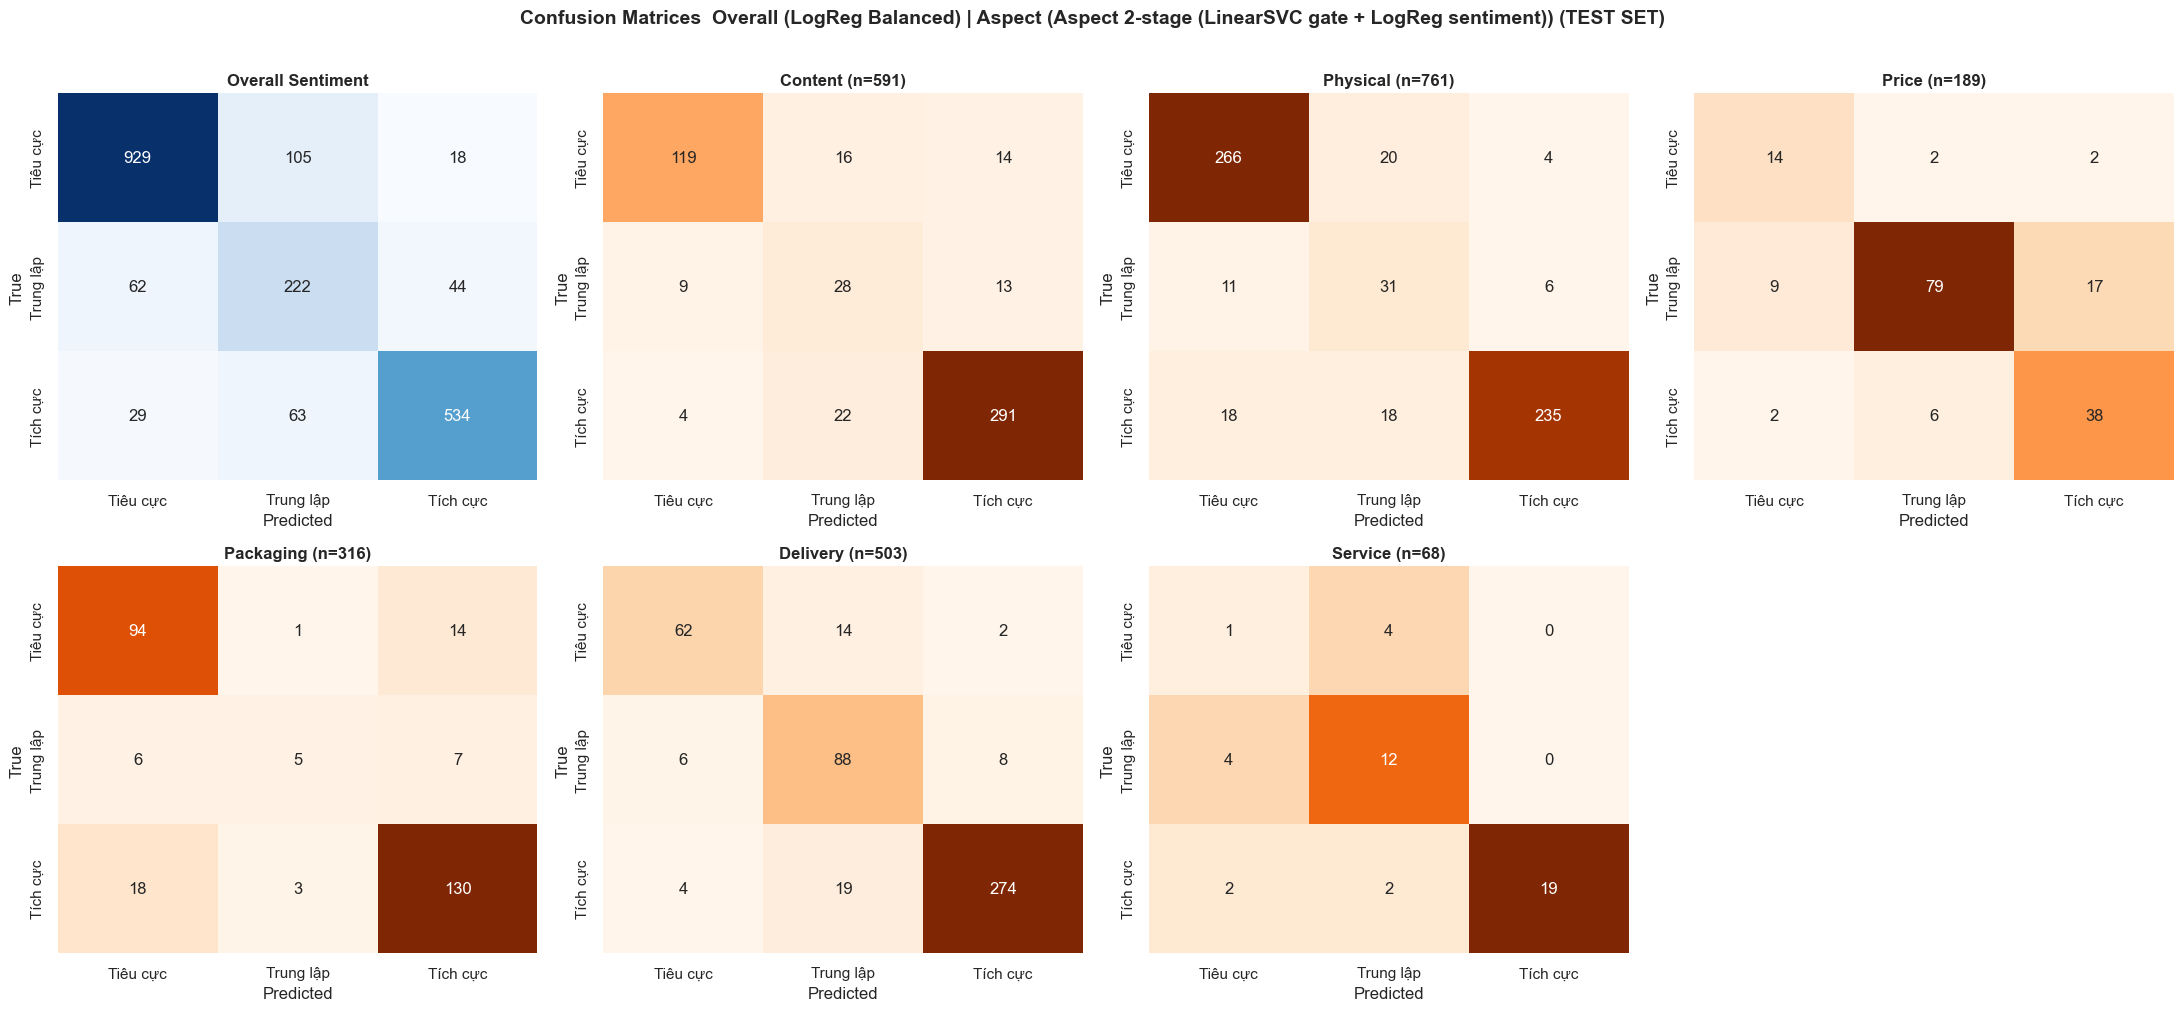

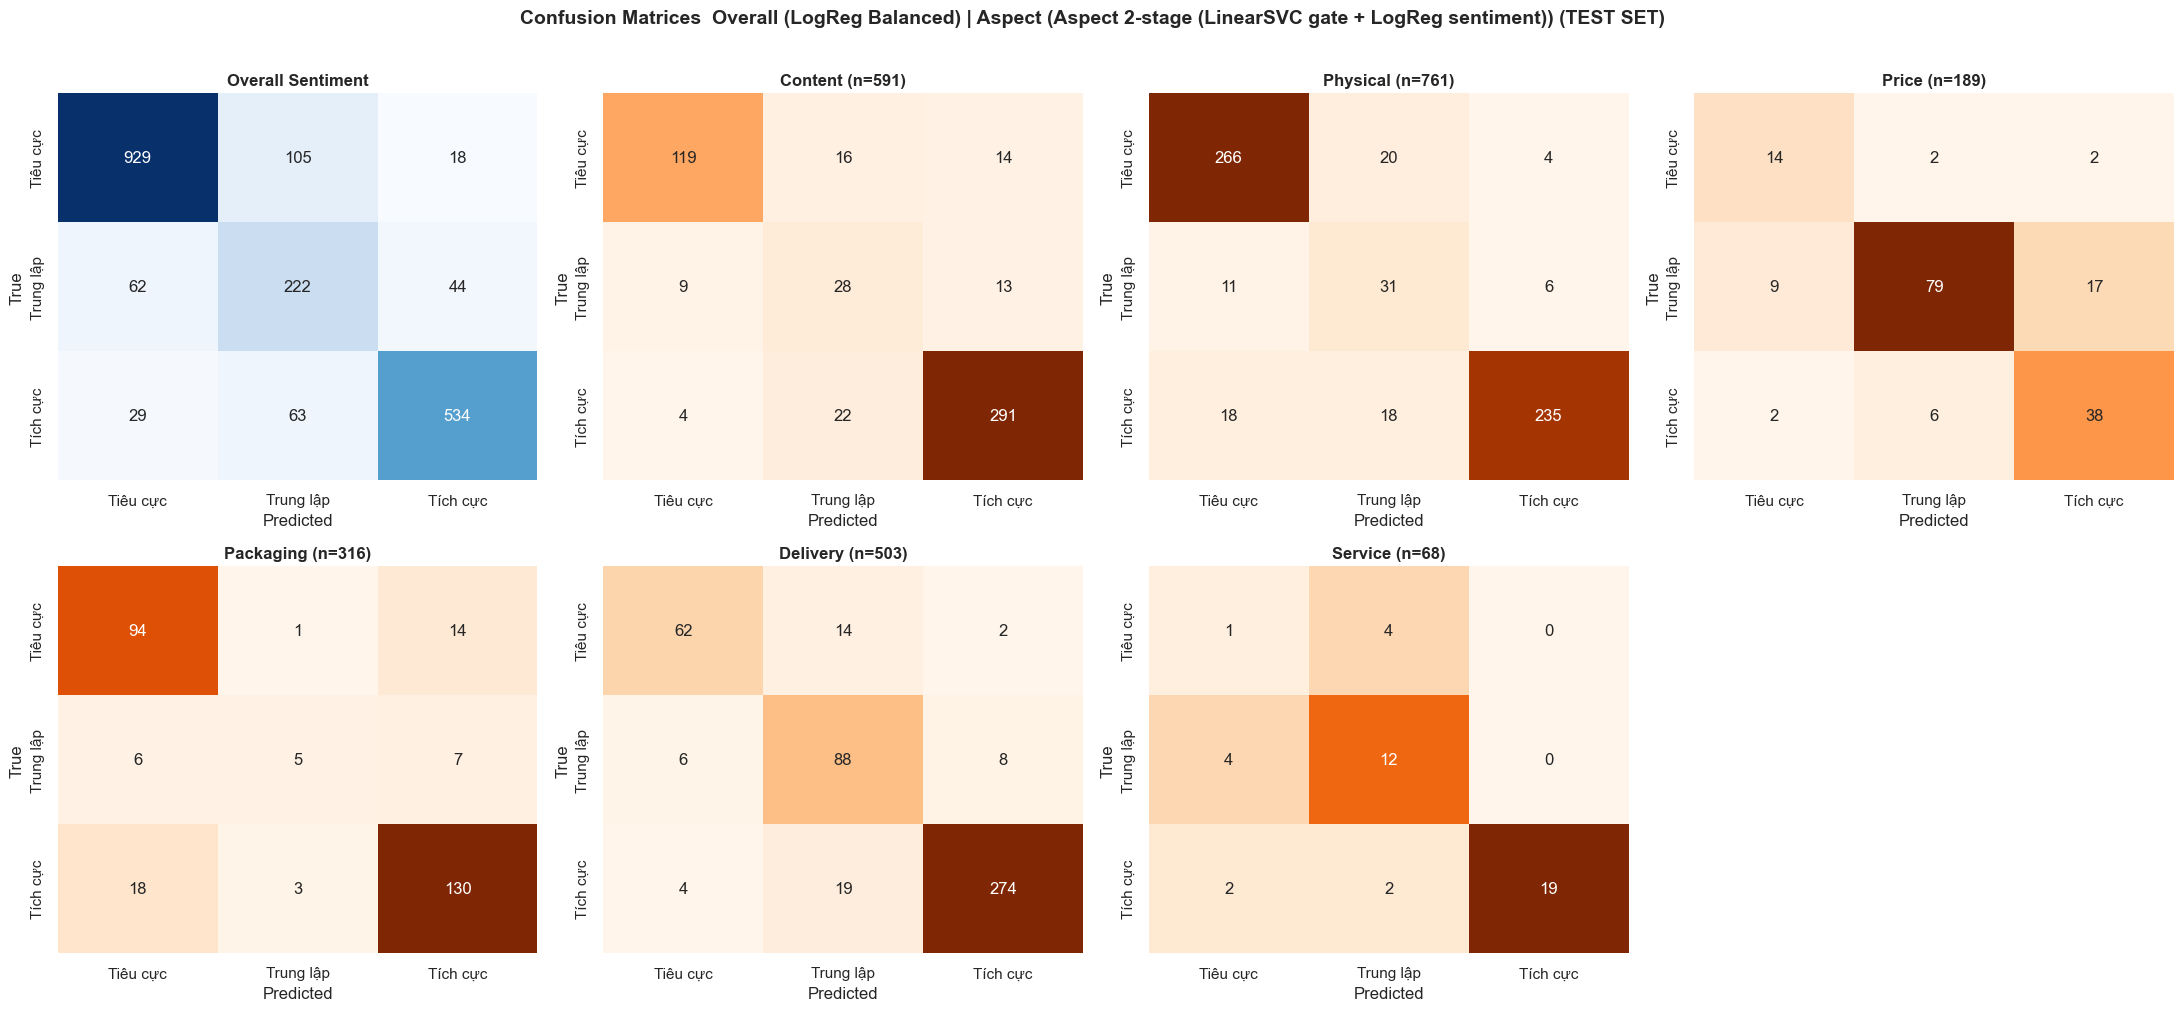

In [25]:
SENTIMENT_TEXT_TO_ID = {v: k for k, v in SENTIMENT_ID_TO_TEXT.items()}
true_sent = np.array([SENTIMENT_TEXT_TO_ID[x] for x in y_sent_test], dtype=int)
pred_sent = np.array([SENTIMENT_TEXT_TO_ID[x] for x in best_overall_pred_test], dtype=int)
true_asps = np.asarray(df_test[ASPECT_COLS].fillna(3), dtype=int)
pred_asps = np.array([SENTIMENT_TEXT_TO_ID.get(x, 3) for x in best_asp_pred_test], dtype=int).reshape(len(ASPECT_COLS), len(df_test)).T

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
NAMES = ['Tiêu cực', 'Trung lập', 'Tích cực']
ASP_DISPLAY = ['Content', 'Physical', 'Price', 'Packaging', 'Delivery', 'Service']

cm_sent = confusion_matrix(true_sent, pred_sent, labels=[0, 1, 2])
sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Blues',
            xticklabels=NAMES, yticklabels=NAMES, ax=axes[0], cbar=False)
axes[0].set_title('Overall Sentiment', fontweight='bold')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

for j, (col, disp) in enumerate(zip(ASPECT_COLS, ASP_DISPLAY)):
    ax = axes[j + 1]
    idx = ASPECT_COLS.index(col)
    tc = true_asps[:, idx]
    pc = pred_asps[:, idx]
    mask = tc != 3
    if not mask.any():
        ax.set_visible(False)
        continue
    cm_asp = confusion_matrix(tc[mask], pc[mask], labels=[0, 1, 2])
    sns.heatmap(cm_asp, annot=True, fmt='d', cmap='Oranges',
                xticklabels=NAMES, yticklabels=NAMES, ax=ax, cbar=False)
    ax.set_title(f'{disp} (n={mask.sum()})', fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

if len(axes) > 7:
    axes[7].set_visible(False)

plt.suptitle(f'Confusion Matrices  Overall ({best_overall_method}) | Aspect ({best_asp_method}) (TEST SET)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
display(fig)
plt.show()


## 12. L&#432;u Artifacts cu&#7889;i

L&#432;u model, vectorizer, features pipeline, predictions, metrics v&#224; config.


In [26]:
# Predictions
df_overall_pred = pd.DataFrame({
    "review_id": df_test["review_id"],
    "y_true": y_sent_test,
    "y_pred": best_overall_pred_test,
})
df_overall_pred.to_csv(ARTIFACT_DIR / "overall_predictions_test.csv", index=False)

df_aspect_pred = df_as_test[["review_id", "aspect", "label"]].copy()
df_aspect_pred["pred_label"] = best_asp_pred_test
df_aspect_pred.to_csv(ARTIFACT_DIR / "aspect_predictions_test.csv", index=False)

# Metrics
summary.to_csv(ARTIFACT_DIR / "metrics_summary.csv", index=False)
stage1_grid.to_csv(ARTIFACT_DIR / "aspect_gate_calibration.csv", index=False)
stage2_grid.to_csv(ARTIFACT_DIR / "aspect_stage2_summary.csv", index=False)

metrics = {
    "overall": {
        "best_method": best_overall_method,
        "best_val_f1": best_overall_val_f1,
        "best_test_f1": best_overall_f1,
    },
    "aspect_two_stage": {
        "stage1_thresholds": best_stage1_thresholds,
        "stage1_gate_val_f1_mean": best_stage1_val_gate_f1,
        "stage1_gate_test_f1_mean": best_stage1_test_gate_f1,
        "stage1_gate_summary": json.loads(stage1_grid.round(6).to_json(orient="records")),
        "stage2_best_c_by_aspect": asp_stage2_best_c,
        "stage2_present_val_f1_by_aspect": asp_stage2_present_val_f1,
        "stage2_present_test_f1_by_aspect": asp_stage2_present_test_f1,
        "stage2_present_val_f1_mean": best_stage2_val_present_f1,
        "stage2_present_test_f1_mean": best_stage2_test_present_f1,
        "stage2_summary": json.loads(stage2_grid.round(6).to_json(orient="records")),
        "val_present_f1": val_aspect_present_f1,
        "test_present_f1": test_aspect_present_f1,
    },
    "val_f1_final": val_f1_final,
    "f1_final": f1_final,
}
(ARTIFACT_DIR / "metrics.json").write_text(json.dumps(metrics, ensure_ascii=False, indent=2), encoding="utf-8")

# Config
config = {
    "project_root": str(PROJECT_ROOT),
    "tfidf_overall": {k: (list(v) if isinstance(v, tuple) else str(v) if callable(v) else v) for k, v in TFIDF_OVERALL_CONFIG.items()},
    "tfidf_overall_char": {k: (list(v) if isinstance(v, tuple) else str(v) if callable(v) else v) for k, v in TFIDF_OVERALL_CHAR_CONFIG.items()},
    "tfidf_aspect": {k: (list(v) if isinstance(v, tuple) else str(v) if callable(v) else v) for k, v in TFIDF_ASPECT_CONFIG.items()},
    "aspect_tfidf_char": {k: (list(v) if isinstance(v, tuple) else str(v) if callable(v) else v) for k, v in TFIDF_ASPECT_CHAR_CONFIG.items()},
    "features": list(feat_train.columns),
    "aspect_names": ASPECT_NAMES,
    "aspect_pipeline": {
        "stage1_model": "LinearSVC per-aspect",
        "stage1_thresholds": best_stage1_thresholds,
        "stage1_gate_val_f1_mean": best_stage1_val_gate_f1,
        "stage1_gate_test_f1_mean": best_stage1_test_gate_f1,
        "stage2_model": "LogisticRegression per-aspect",
        "stage2_best_c_by_aspect": asp_stage2_best_c,
        "stage2_present_val_f1_mean": best_stage2_val_present_f1,
        "stage2_present_test_f1_mean": best_stage2_test_present_f1,
    },
    "class_weight": "balanced",
}
(ARTIFACT_DIR / "config.json").write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")

# Models
joblib.dump(lr_model, ARTIFACT_DIR / "overall_logreg.joblib")
joblib.dump(tfidf_overall, ARTIFACT_DIR / "overall_tfidf.joblib")
joblib.dump(tfidf_overall_char, ARTIFACT_DIR / "overall_tfidf_char.joblib")
joblib.dump(aspect_tfidf_word, ARTIFACT_DIR / "aspect_tfidf_word.joblib")
joblib.dump(aspect_tfidf_char, ARTIFACT_DIR / "aspect_tfidf_char.joblib")
joblib.dump(asp_stage1_models, ARTIFACT_DIR / "aspect_stage1_gates.joblib")
joblib.dump({
    "models": asp_stage2_models,
    "best_c_by_aspect": asp_stage2_best_c,
    "present_val_f1_by_aspect": asp_stage2_present_val_f1,
    "present_test_f1_by_aspect": asp_stage2_present_test_f1,
}, ARTIFACT_DIR / "aspect_stage2_sentiment.joblib")

print()
print(f"Artifacts saved at: {ARTIFACT_DIR}")



Artifacts saved at: d:\DataPreprocessing\DoAn2\artifacts\classic_ml_absa_v2
